In [2]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
from turbos.sim.p3d.p3d_2 import P3D
import matplotlib.pyplot as plt

In [4]:
run = P3D(
    "/archive/tulasi/149p6_rs",
    filenum="000",
)

ds = run.load_xarray(0, variables=['Pe', 'ue', 'Pi', 'ui'])
print(ds)

<xarray.Dataset> Size: 3GB
Dimensions:  (x: 4096, y: 4096, j: 3, i: 3, c: 3)
Coordinates:
  * x        (x) float64 33kB 0.0 0.03651 0.07303 0.1095 ... 149.5 149.5 149.5
  * y        (y) float64 33kB 0.0 0.03651 0.07303 0.1095 ... 149.5 149.5 149.5
  * j        (j) <U1 12B 'x' 'y' 'z'
  * i        (i) <U1 12B 'x' 'y' 'z'
  * c        (c) <U1 12B 'x' 'y' 'z'
Data variables:
    Pe       (x, y, i, j) float64 1GB 0.2916 -0.005824 ... 0.01334 0.3589
    ue       (x, y, c) float64 403MB -0.08108 0.1369 0.1796 ... 0.1464 0.2062
    Pi       (x, y, i, j) float64 1GB 0.3099 -0.00356 ... -0.006017 0.2951
    ui       (x, y, c) float64 403MB 0.04531 0.05868 ... 0.0667 -0.08341
Attributes:
    time:      0.0
    run:       149p6_rs
    snapshot:  0
    format:    movie


In [18]:
from turbos.pressure_strain import pressure_strain

ds['PiDe'] = pressure_strain(ds['Pe'], ds['ue'])['PiD']

ds['PiDi'] = pressure_strain(ds['Pi'], ds['ui'])['PiD']


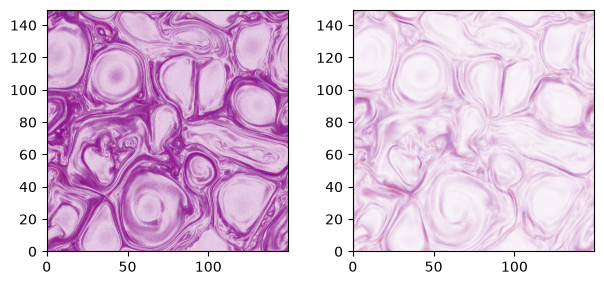

In [ ]:
f, ax = plt.subplots(1,2)
c0 = ax[0].imshow(ds['PiDe'], cmap = 'bwr', extent=[ds.x.values[0], ds.x.values[-1], ds.y.values[0], ds.y.values[-1]])
c0.set_clim(-0.02, 0.02)
ax[0].set_box_aspect(1)

c1 = ax[1].imshow(ds['PiDi'], cmap = 'bwr', extent=[ds.x.values[0], ds.x.values[-1], ds.y.values[0], ds.y.values[-1]])
c1.set_clim(-0.02, 0.02)
# f.colorbar(c1, ax=ax[1])
ax[1].set_box_aspect(1)

plt.tight_layout()
plt.show()

In [20]:
import numpy as np
np.mean(ds['PiDi'])

<xarray.DataArray 'PiDi' ()> Size: 8B
array(7.23867587e-05)